# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Burnout Dropout Dataset](https://www.kaggle.com/datasets/harpartapsingh13/student-burnout-and-dropout-risk-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/harpartapsingh13/student-burnout-and-dropout-risk-dataset/student_burnout_dropout_dataset_2.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_burnout_dropout_dataset_2.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
795,STU00796,21,Male,4,Law,PG/Rented,68.1,0.8,5.84,0.0,...,Middle,3.3,NaN,6.6,4.8,10.0,4.9,Yes,Low,No
796,STU00797,25,Male,2,Engineering,Hostel,91.0,0.0,7.04,1.0,...,Middle,4.3,NaN,6.7,NaN,3.3,4.6,Yes,High,Yes
797,STU00798,17,Female,4,Arts,PG/Rented,NaN,4.9,3.51,1.0,...,Low,7.6,7.4,6.0,7.3,4.2,4.5,No,High,Yes
798,STU00799,25,Female,3,Science,Day Scholar,84.9,NaN,9.24,1.0,...,Middle,6.3,7.4,6.8,4.7,6.9,NaN,No,Low,No
799,STU00800,24,Female,1,Science,PG/Rented,NaN,3.1,5.80,1.0,...,Lower-Middle,6.1,10.0,4.9,4.2,6.8,5.1,No,Medium,No


## Shape of our dataset

In [5]:
df.shape

(800, 25)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Year_of_Study', 'Department',
       'Residence_Type', 'Attendance_Percent', 'Study_Hours_Per_Day',
       'Previous_GPA', 'Backlogs', 'Sleep_Hours', 'Screen_Time_Hours',
       'Exercise_Freq_Per_Week', 'Social_Activity_Score', 'Part_Time_Job',
       'Family_Income_Bracket', 'Financial_Stress_Score',
       'Family_Support_Score', 'Stress_Level', 'Anxiety_Score',
       'Motivation_Score', 'Peer_Pressure_Score', 'Counseling_Access',
       'Burnout_Level', 'Dropout_Risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                 object
Age                         int64
Gender                     object
Year_of_Study               int64
Department                 object
Residence_Type             object
Attendance_Percent        float64
Study_Hours_Per_Day       float64
Previous_GPA              float64
Backlogs                  float64
Sleep_Hours               float64
Screen_Time_Hours         float64
Exercise_Freq_Per_Week      int64
Social_Activity_Score     float64
Part_Time_Job              object
Family_Income_Bracket      object
Financial_Stress_Score    float64
Family_Support_Score      float64
Stress_Level              float64
Anxiety_Score             float64
Motivation_Score          float64
Peer_Pressure_Score       float64
Counseling_Access          object
Burnout_Level              object
Dropout_Risk               object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              800 non-null    object 
 1   Age                     800 non-null    int64  
 2   Gender                  770 non-null    object 
 3   Year_of_Study           800 non-null    int64  
 4   Department              777 non-null    object 
 5   Residence_Type          783 non-null    object 
 6   Attendance_Percent      749 non-null    float64
 7   Study_Hours_Per_Day     765 non-null    float64
 8   Previous_GPA            765 non-null    float64
 9   Backlogs                785 non-null    float64
 10  Sleep_Hours             765 non-null    float64
 11  Screen_Time_Hours       764 non-null    float64
 12  Exercise_Freq_Per_Week  800 non-null    int64  
 13  Social_Activity_Score   760 non-null    float64
 14  Part_Time_Job           775 non-null    ob

## Before Handle Check Null Value

In [9]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                    30
Year_of_Study              0
Department                23
Residence_Type            17
Attendance_Percent        51
Study_Hours_Per_Day       35
Previous_GPA              35
Backlogs                  15
Sleep_Hours               35
Screen_Time_Hours         36
Exercise_Freq_Per_Week     0
Social_Activity_Score     40
Part_Time_Job             25
Family_Income_Bracket     13
Financial_Stress_Score    43
Family_Support_Score      44
Stress_Level              49
Anxiety_Score             39
Motivation_Score          41
Peer_Pressure_Score       41
Counseling_Access          0
Burnout_Level              0
Dropout_Risk               0
dtype: int64

## select numerical columns

In [10]:
num_cols = df.select_dtypes(include=['number']).columns

## select categorical columns

In [11]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

## fill numerical missing values with median

In [12]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## fill categorical missing values with mode

In [13]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## show missing values after filling

In [14]:
print("\nMissing values after:\n", df.isnull().sum())


Missing values after:
 Student_ID                0
Age                       0
Gender                    0
Year_of_Study             0
Department                0
Residence_Type            0
Attendance_Percent        0
Study_Hours_Per_Day       0
Previous_GPA              0
Backlogs                  0
Sleep_Hours               0
Screen_Time_Hours         0
Exercise_Freq_Per_Week    0
Social_Activity_Score     0
Part_Time_Job             0
Family_Income_Bracket     0
Financial_Stress_Score    0
Family_Support_Score      0
Stress_Level              0
Anxiety_Score             0
Motivation_Score          0
Peer_Pressure_Score       0
Counseling_Access         0
Burnout_Level             0
Dropout_Risk              0
dtype: int64


## Check Dupicate Value

In [15]:
df.duplicated().sum()

np.int64(0)

## Summary

In [16]:
df.describe()

,Age,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,Screen_Time_Hours,Exercise_Freq_Per_Week,Social_Activity_Score,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,20.883750,2.281250,76.917125,3.155875,6.859275,0.827500,6.204250,5.433250,2.011250,4.994875,5.024500,6.423625,5.515625,4.988625,5.467125,4.484875
std,2.602153,1.105068,13.796175,1.524236,1.370079,0.930767,1.466405,2.150125,1.480325,1.911650,2.174894,2.029545,1.886164,2.053358,1.990543,1.845329
min,17.000000,1.000000,30.000000,0.000000,2.420000,0.000000,2.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000
25%,19.000000,1.000000,66.900000,2.200000,5.910000,0.000000,5.200000,4.000000,1.000000,3.700000,3.600000,5.100000,4.300000,3.600000,4.200000,3.300000
50%,21.000000,2.000000,77.400000,3.100000,6.860000,1.000000,6.300000,5.450000,2.000000,5.000000,5.000000,6.500000,5.500000,5.100000,5.400000,4.500000
75%,23.000000,3.000000,87.525000,4.200000,7.750000,1.000000,7.100000,6.900000,3.000000,6.300000,6.500000,7.800000,6.700000,6.400000,6.800000,5.625000
max,25.000000,4.000000,100.000000,8.100000,10.000000,6.000000,10.000000,12.600000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.800000


# EDA

In [17]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

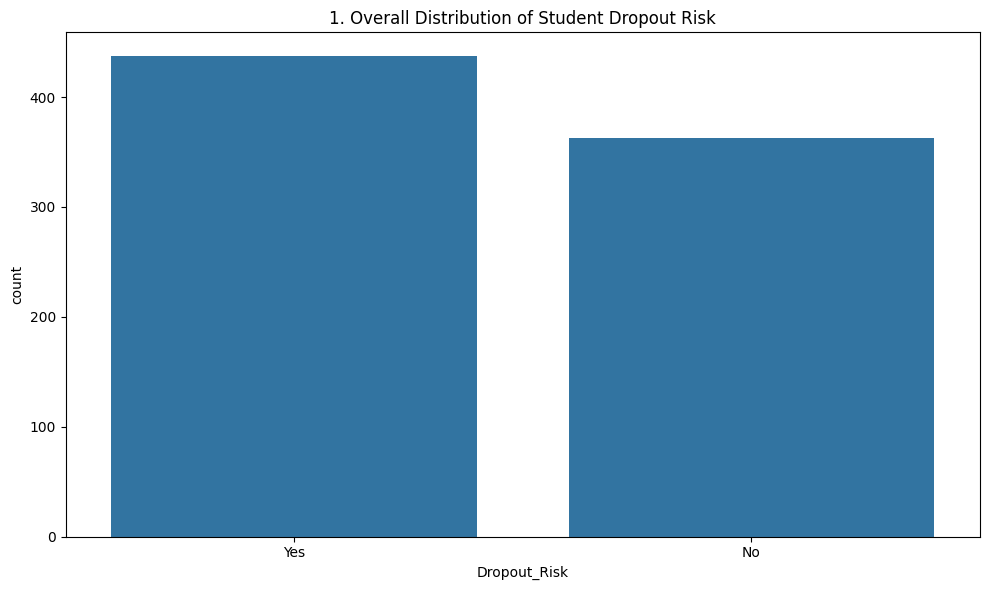

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Dropout_Risk', order=df['Dropout_Risk'].value_counts().index)
plt.title(f'{plot_no}. Overall Distribution of Student Dropout Risk')
show_fig()
plot_no += 1

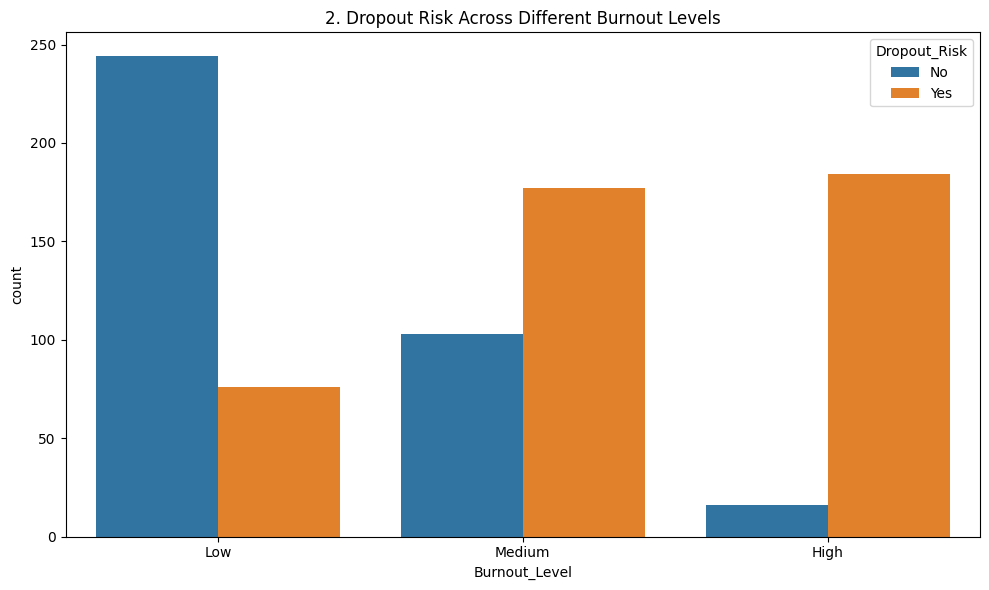

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Burnout_Level', hue='Dropout_Risk', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Dropout Risk Across Different Burnout Levels')
show_fig()
plot_no += 1

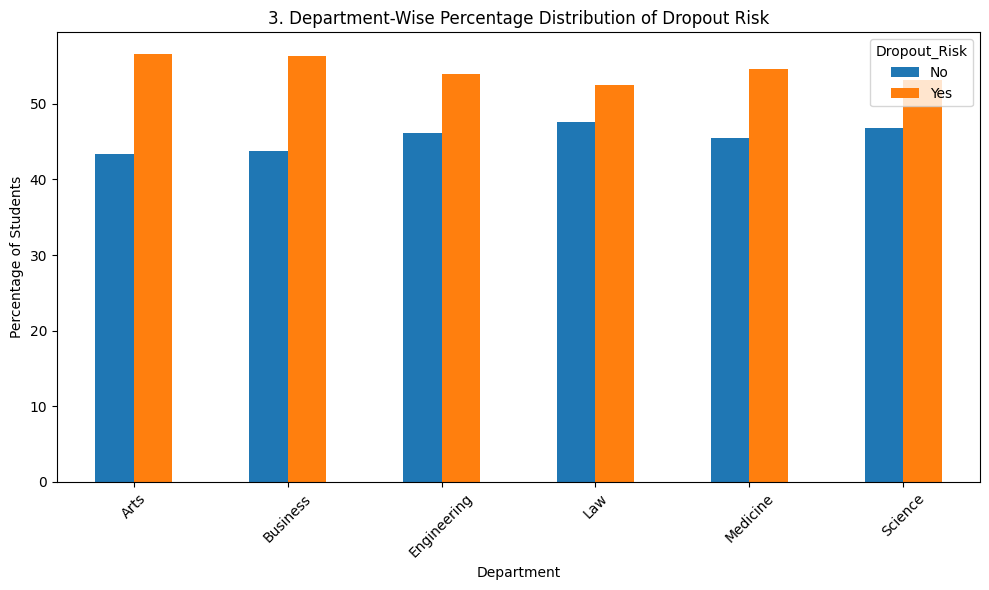

In [20]:
department_dropout = pd.crosstab(df['Department'], df['Dropout_Risk'], normalize='index') * 100
fig = plt.figure(figsize=(10,6))
department_dropout.plot(kind='bar', ax=plt.gca())
plt.ylabel('Percentage of Students')
plt.title(f'{plot_no}. Department-Wise Percentage Distribution of Dropout Risk')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

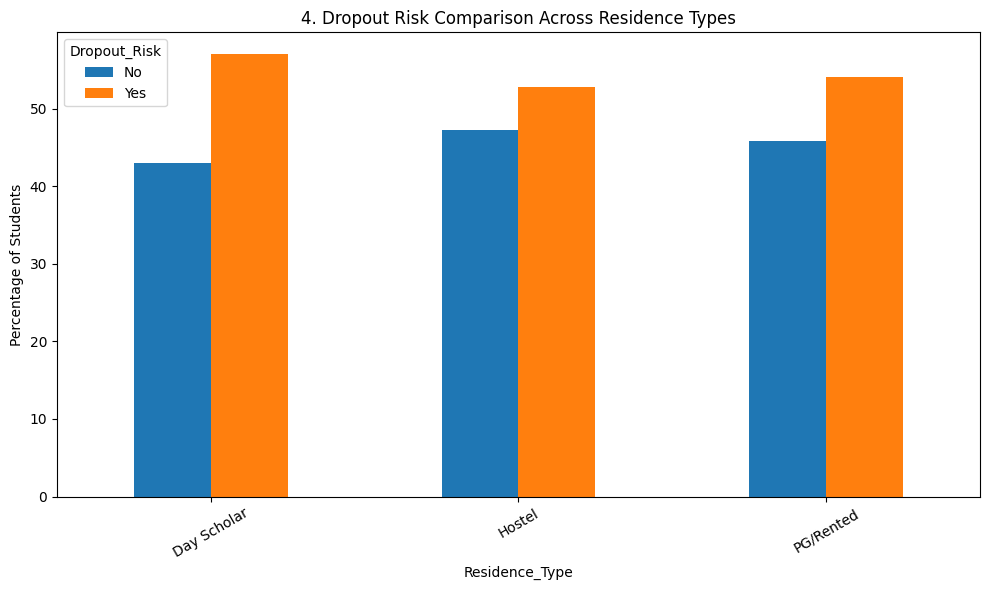

In [21]:
residence_dropout = pd.crosstab(df['Residence_Type'], df['Dropout_Risk'], normalize='index') * 100
fig = plt.figure(figsize=(10,6))
residence_dropout.plot(kind='bar', ax=plt.gca())
plt.ylabel('Percentage of Students')
plt.title(f'{plot_no}. Dropout Risk Comparison Across Residence Types')
plt.xticks(rotation=30)
show_fig()
plot_no += 1

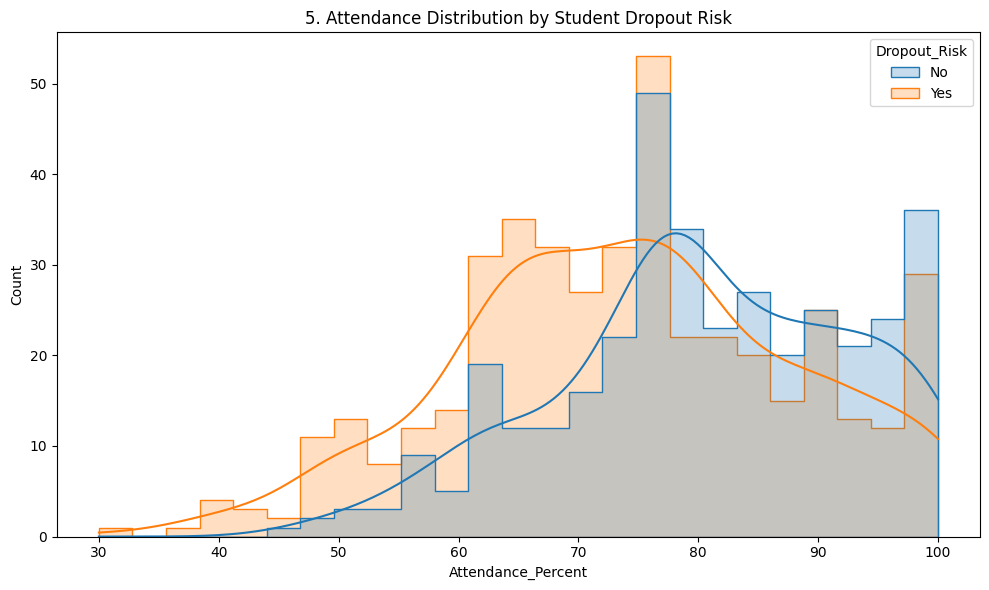

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Attendance_Percent', hue='Dropout_Risk', kde=True, bins=25, element='step')
plt.title(f'{plot_no}. Attendance Distribution by Student Dropout Risk')
show_fig()
plot_no += 1

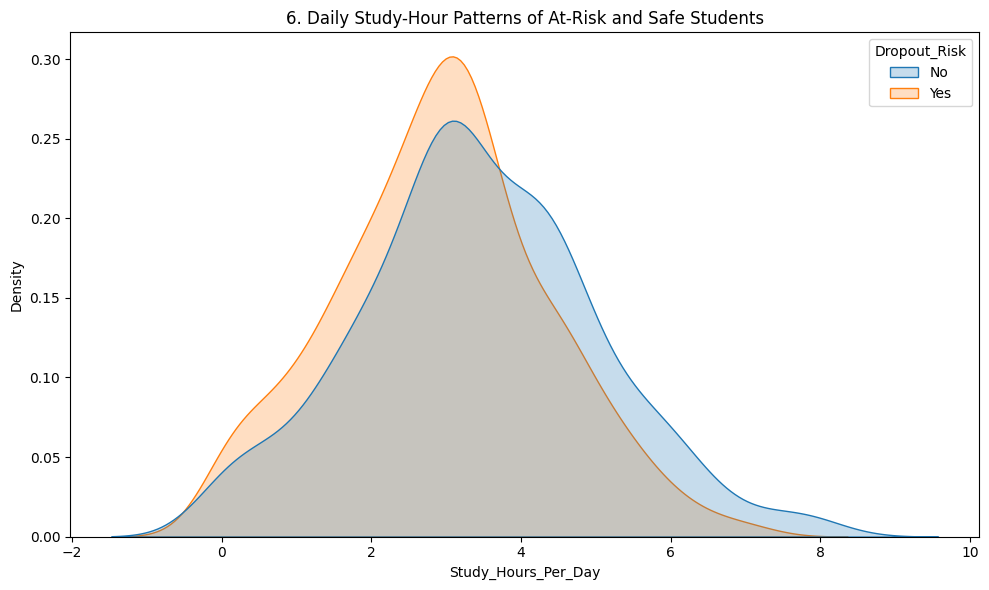

In [23]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Study_Hours_Per_Day', hue='Dropout_Risk', fill=True, common_norm=False)
plt.title(f'{plot_no}. Daily Study-Hour Patterns of At-Risk and Safe Students')
show_fig()
plot_no += 1

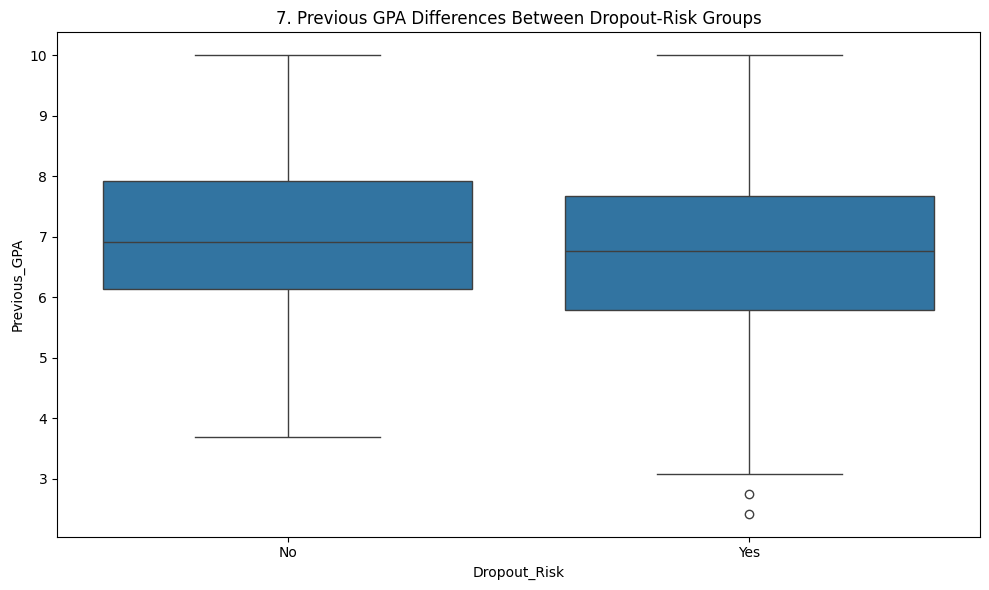

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Dropout_Risk', y='Previous_GPA')
plt.title(f'{plot_no}. Previous GPA Differences Between Dropout-Risk Groups')
show_fig()
plot_no += 1

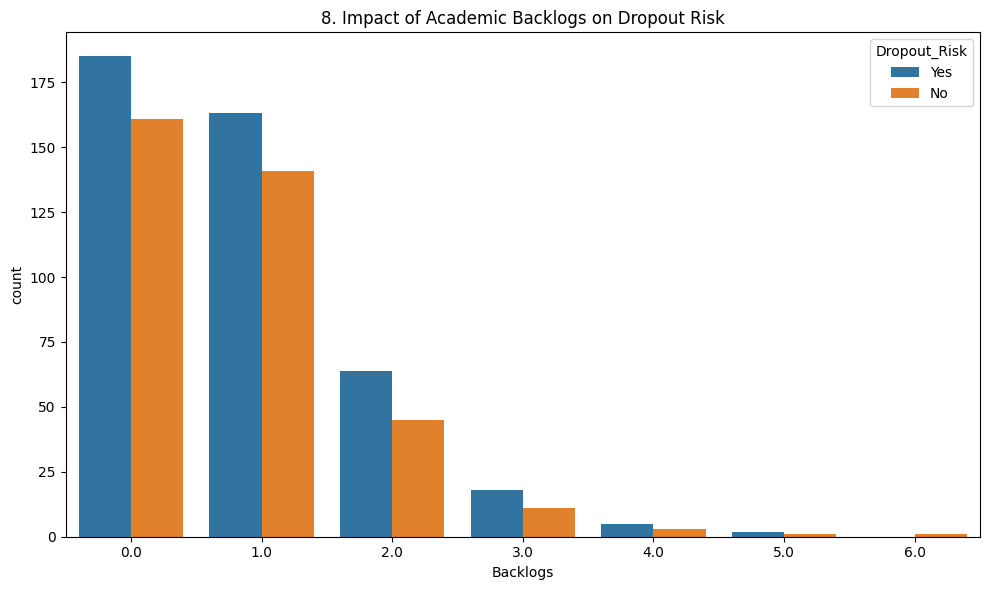

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Backlogs', hue='Dropout_Risk')
plt.title(f'{plot_no}. Impact of Academic Backlogs on Dropout Risk')
show_fig()
plot_no += 1

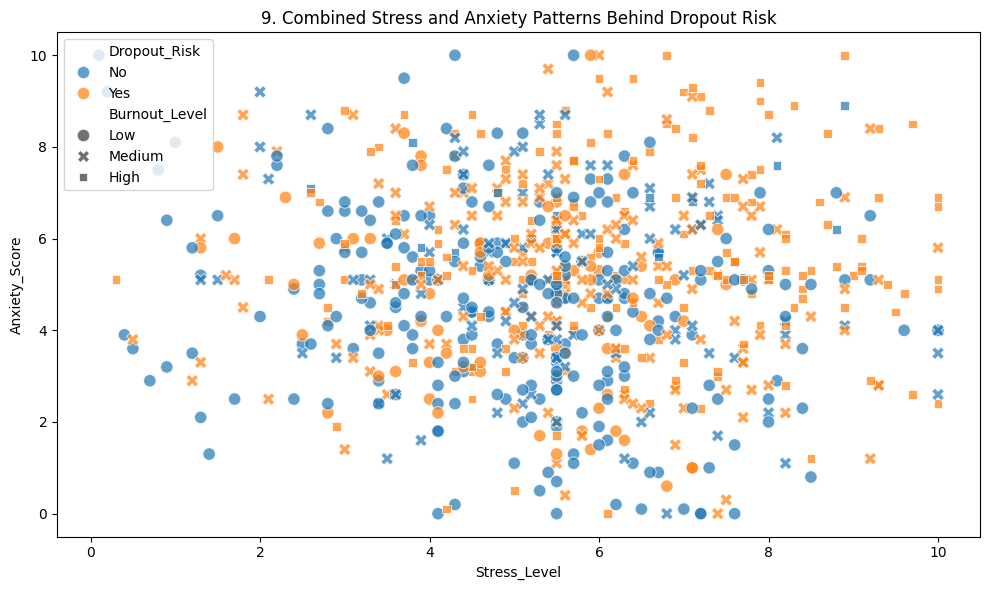

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Stress_Level', y='Anxiety_Score', hue='Dropout_Risk', style='Burnout_Level', s=80, alpha=0.7)
plt.title(f'{plot_no}. Combined Stress and Anxiety Patterns Behind Dropout Risk')
show_fig()
plot_no += 1

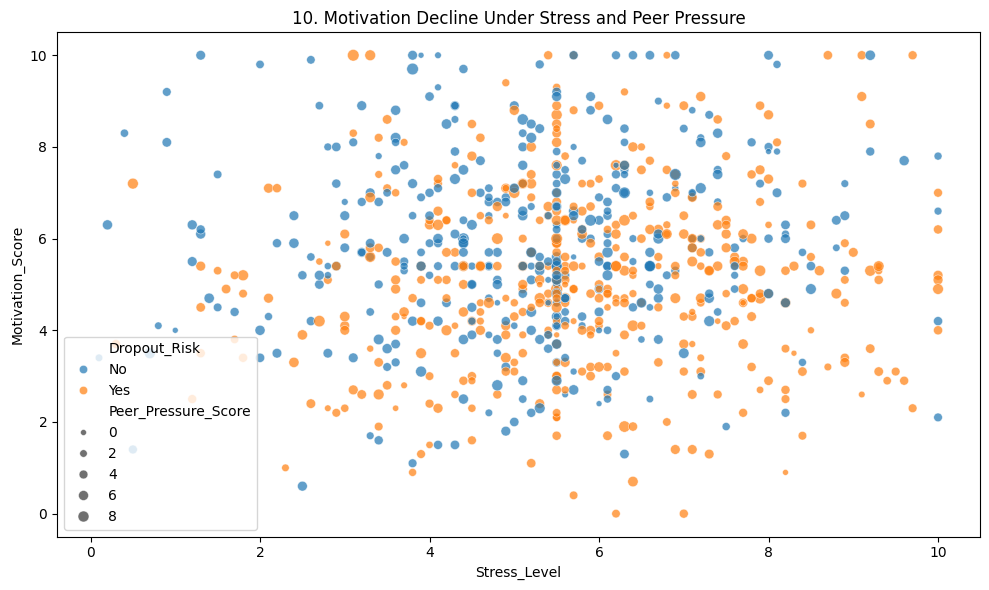

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Stress_Level', y='Motivation_Score', hue='Dropout_Risk', size='Peer_Pressure_Score', alpha=0.7)
plt.title(f'{plot_no}. Motivation Decline Under Stress and Peer Pressure')
show_fig()
plot_no += 1

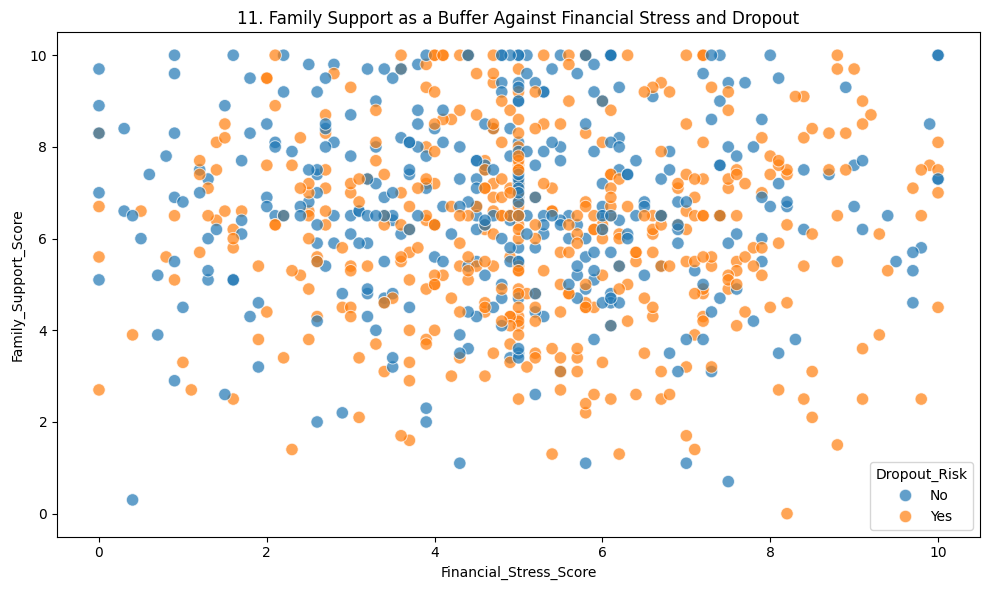

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Financial_Stress_Score', y='Family_Support_Score', hue='Dropout_Risk', s=80, alpha=0.7)
plt.title(f'{plot_no}. Family Support as a Buffer Against Financial Stress and Dropout')
show_fig()
plot_no += 1

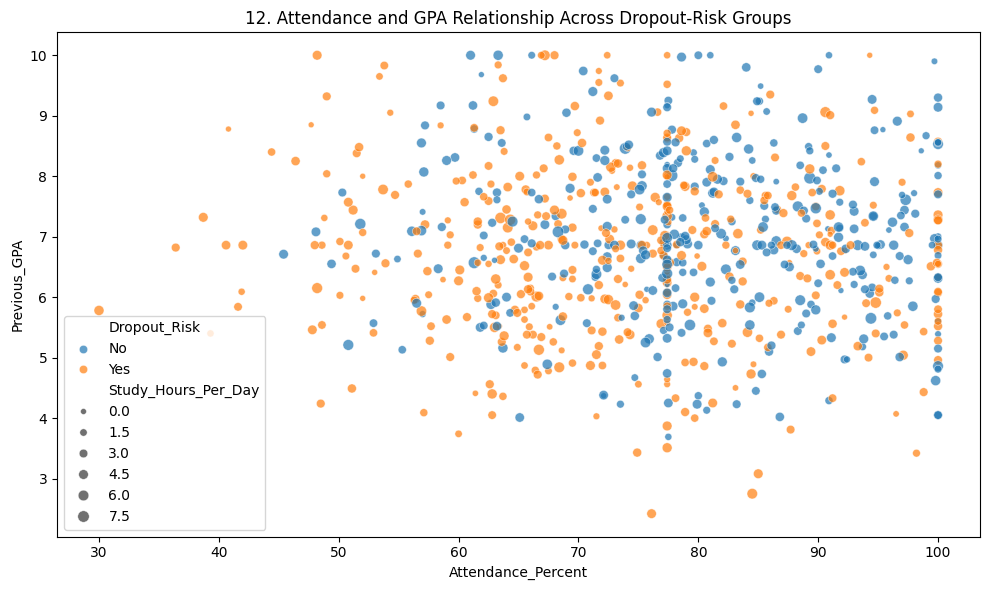

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attendance_Percent', y='Previous_GPA', hue='Dropout_Risk', size='Study_Hours_Per_Day', alpha=0.7)
plt.title(f'{plot_no}. Attendance and GPA Relationship Across Dropout-Risk Groups')
show_fig()
plot_no += 1

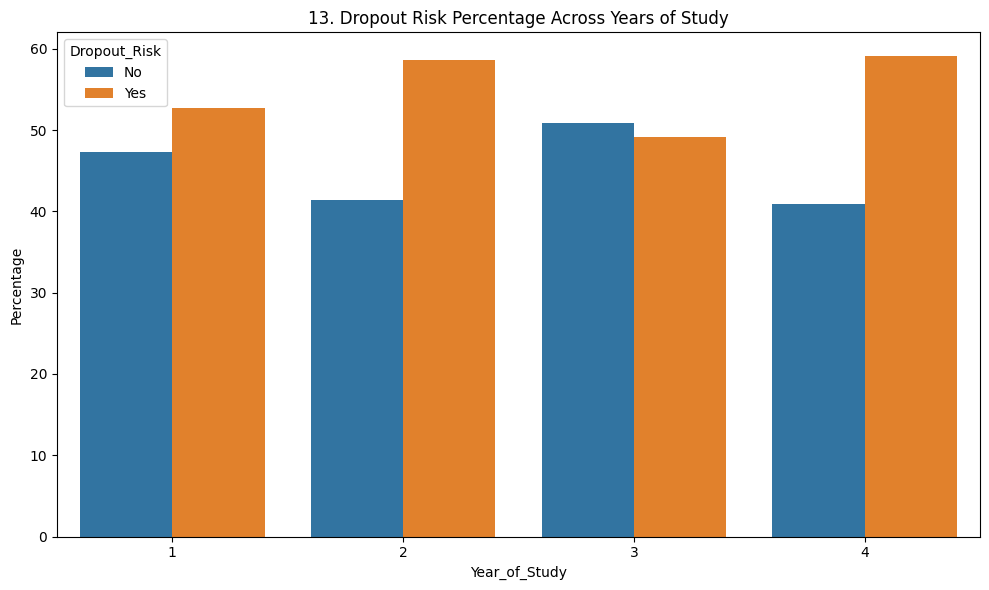

In [30]:
year_dropout = pd.crosstab(df['Year_of_Study'], df['Dropout_Risk'], normalize='index').mul(100).reset_index()
year_dropout = year_dropout.melt(id_vars='Year_of_Study', var_name='Dropout_Risk', value_name='Percentage')
fig = plt.figure(figsize=(10,6))
sns.barplot(data=year_dropout, x='Year_of_Study', y='Percentage', hue='Dropout_Risk')
plt.title(f'{plot_no}. Dropout Risk Percentage Across Years of Study')
show_fig()
plot_no += 1

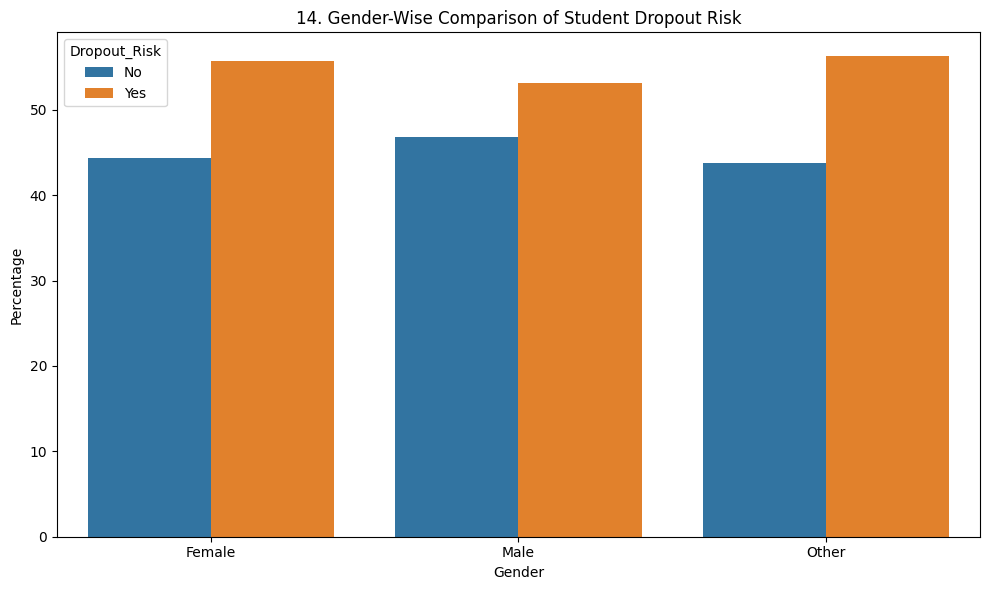

In [31]:
gender_dropout = pd.crosstab(df['Gender'], df['Dropout_Risk'], normalize='index').mul(100).reset_index()
gender_dropout = gender_dropout.melt(id_vars='Gender', var_name='Dropout_Risk', value_name='Percentage')
fig = plt.figure(figsize=(10,6))
sns.barplot(data=gender_dropout, x='Gender', y='Percentage', hue='Dropout_Risk')
plt.title(f'{plot_no}. Gender-Wise Comparison of Student Dropout Risk')
show_fig()
plot_no += 1

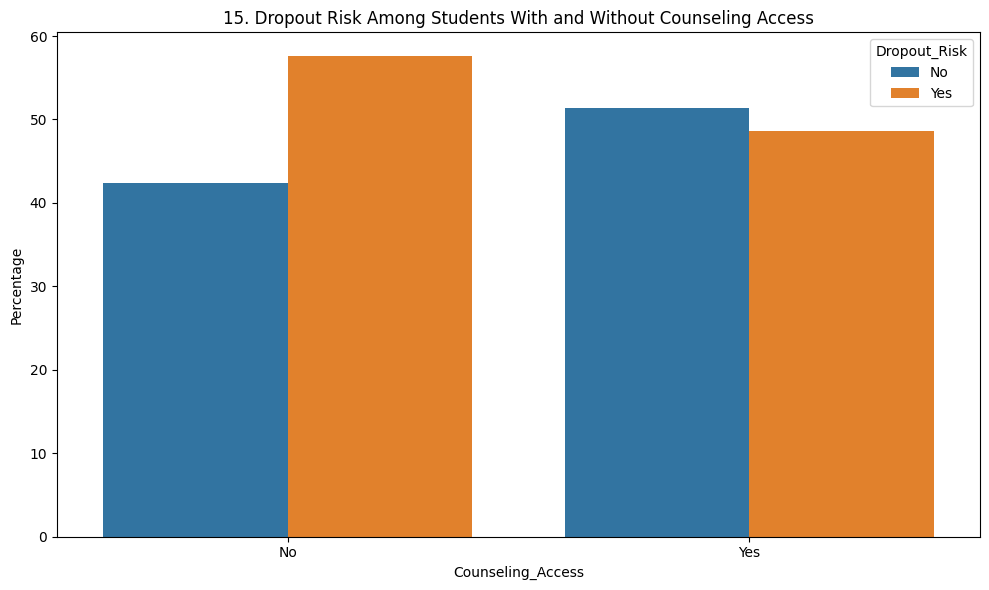

In [32]:
counseling_dropout = pd.crosstab(df['Counseling_Access'], df['Dropout_Risk'], normalize='index').mul(100).reset_index()
counseling_dropout = counseling_dropout.melt(id_vars='Counseling_Access', var_name='Dropout_Risk', value_name='Percentage')
fig = plt.figure(figsize=(10,6))
sns.barplot(data=counseling_dropout, x='Counseling_Access', y='Percentage', hue='Dropout_Risk')
plt.title(f'{plot_no}. Dropout Risk Among Students With and Without Counseling Access')
show_fig()
plot_no += 1

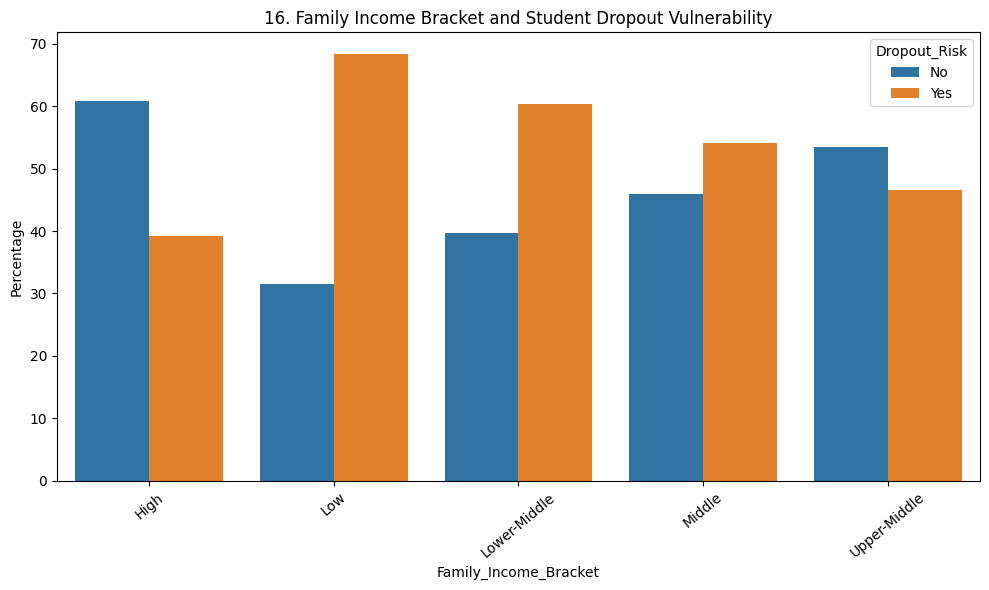

In [33]:
income_dropout = pd.crosstab(df['Family_Income_Bracket'], df['Dropout_Risk'], normalize='index').mul(100).reset_index()
income_dropout = income_dropout.melt(id_vars='Family_Income_Bracket', var_name='Dropout_Risk', value_name='Percentage')
fig = plt.figure(figsize=(10,6))
sns.barplot(data=income_dropout, x='Family_Income_Bracket', y='Percentage', hue='Dropout_Risk')
plt.title(f'{plot_no}. Family Income Bracket and Student Dropout Vulnerability')
plt.xticks(rotation=40)
show_fig()
plot_no += 1

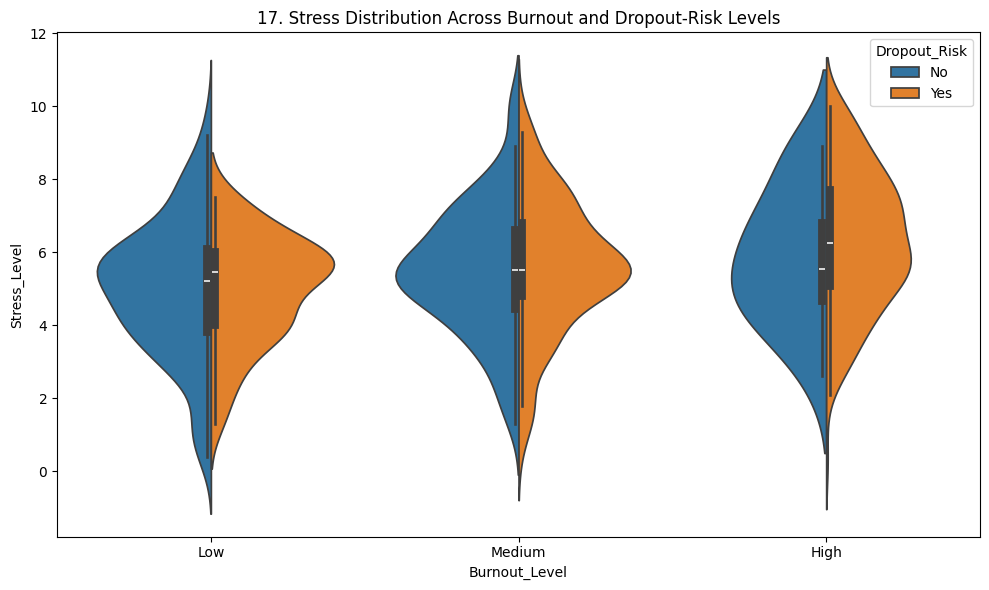

In [34]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Burnout_Level', y='Stress_Level', hue='Dropout_Risk', order=['Low', 'Medium', 'High'], split=True)
plt.title(f'{plot_no}. Stress Distribution Across Burnout and Dropout-Risk Levels')
show_fig()
plot_no += 1

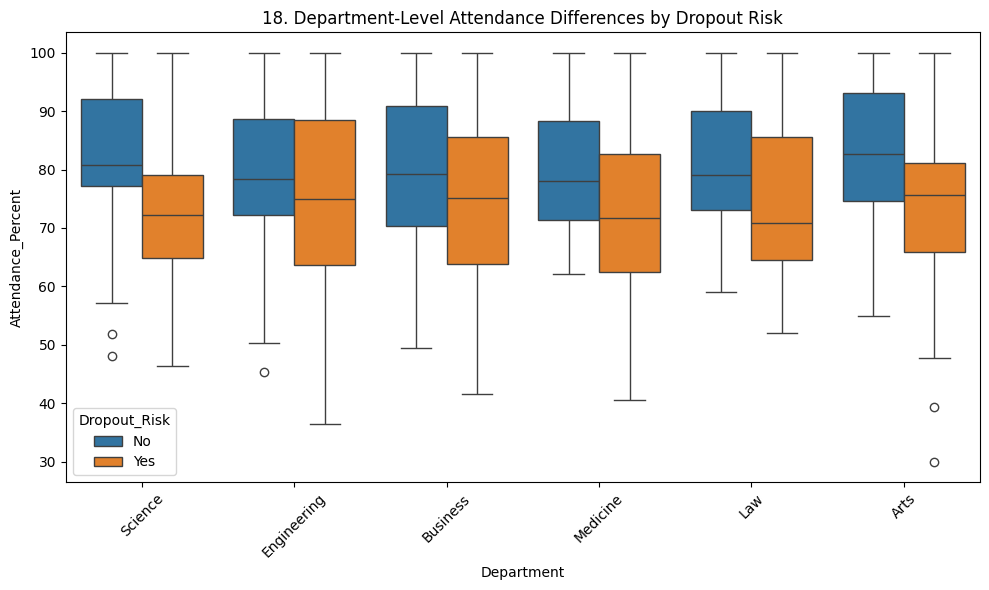

In [35]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Department', y='Attendance_Percent', hue='Dropout_Risk')
plt.title(f'{plot_no}. Department-Level Attendance Differences by Dropout Risk')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

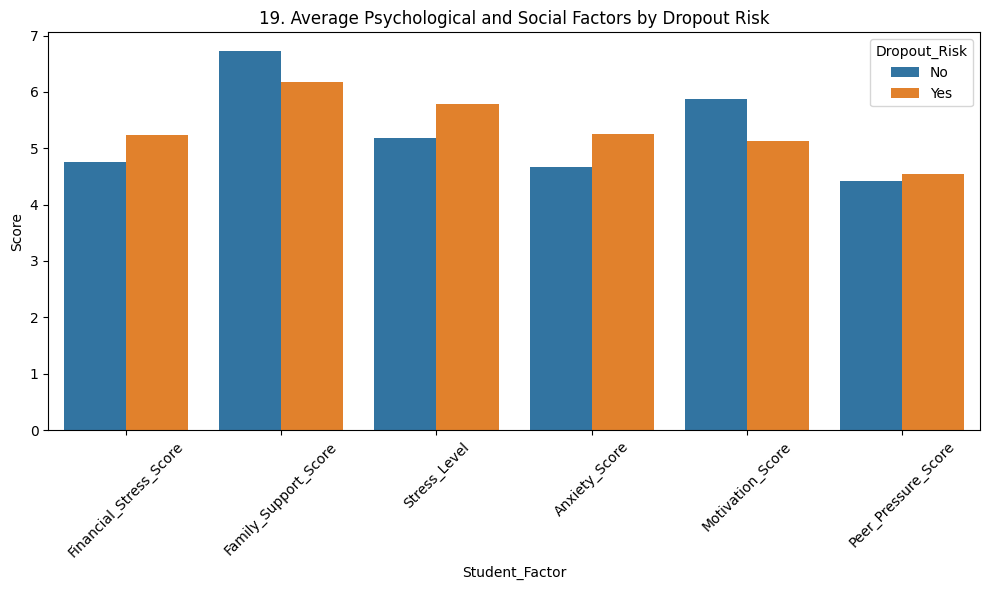

In [36]:
psychological_metrics = df.melt(
    id_vars='Dropout_Risk',
    value_vars=[
        'Financial_Stress_Score',
        'Family_Support_Score',
        'Stress_Level',
        'Anxiety_Score',
        'Motivation_Score',
        'Peer_Pressure_Score'
    ],
    var_name='Student_Factor',
    value_name='Score'
)
fig = plt.figure(figsize=(10,6))
sns.barplot(data=psychological_metrics, x='Student_Factor', y='Score', hue='Dropout_Risk', errorbar=None)
plt.title(f'{plot_no}. Average Psychological and Social Factors by Dropout Risk')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

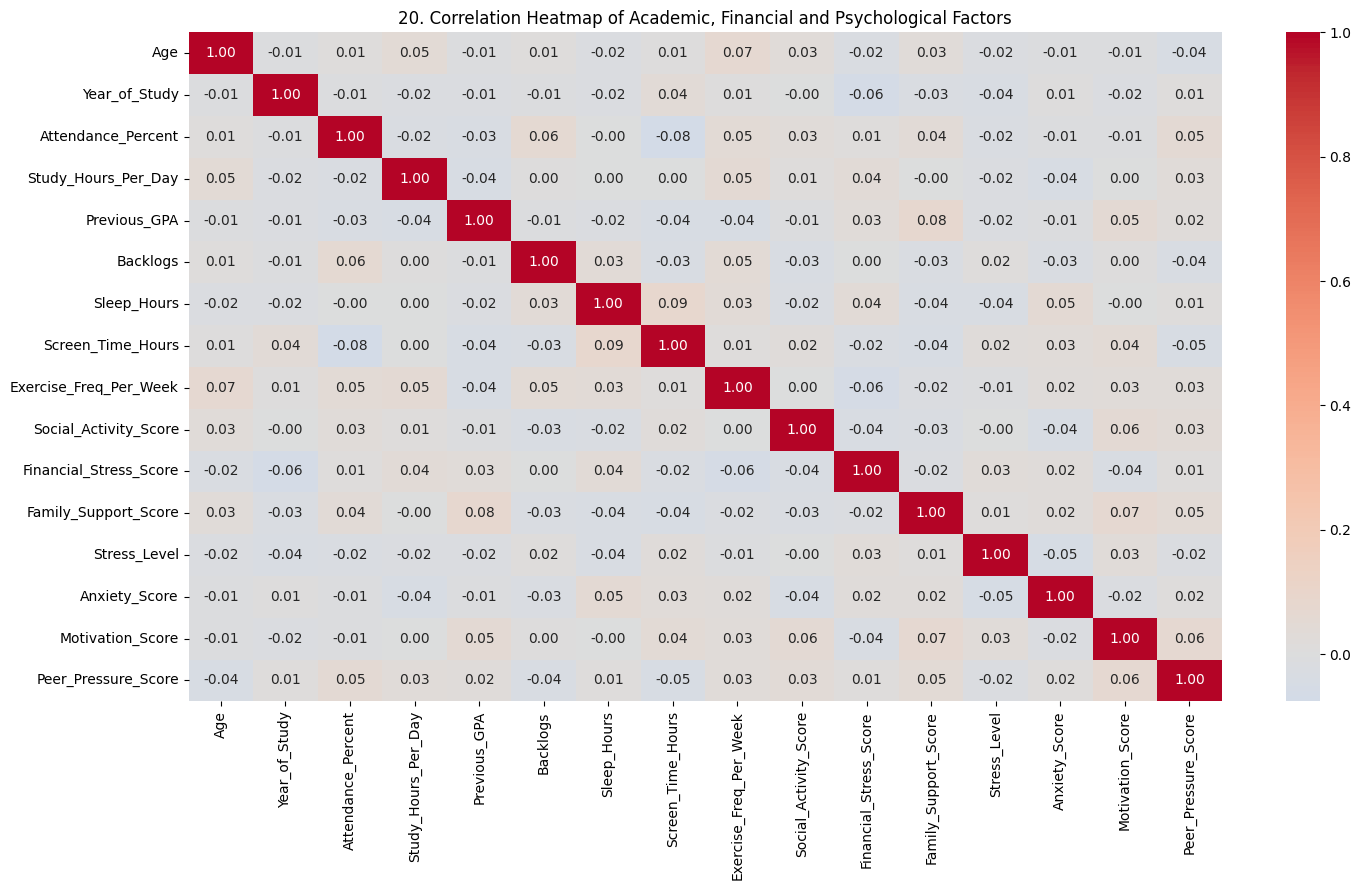

In [37]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Academic, Financial and Psychological Factors')
show_fig()
plot_no += 1

# Model Training

## select target column

In [38]:
target = 'Dropout_Risk'

## create input and output data

In [39]:
X = df.drop(columns=[target, 'Student_ID'], errors='ignore')
y = df[target]

## remove rows with missing target values

In [40]:
valid_rows = y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

## encode target values

In [41]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

## identify numerical and categorical columns

In [42]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns

## create numerical preprocessing

In [43]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

## create categorical preprocessing

In [44]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## combine preprocessing steps

In [45]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## create classification pipeline

In [46]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

## define model parameters

In [47]:
parameter_grid = {
    'classifier__learning_rate': [0.02, 0.03, 0.05, 0.08, 0.10],
    'classifier__max_iter': [200, 300, 400, 500],
    'classifier__max_leaf_nodes': [15, 31, 63],
    'classifier__max_depth': [None, 5, 8, 12],
    'classifier__min_samples_leaf': [10, 15, 20, 30, 40],
    'classifier__l2_regularization': [0.0, 0.1, 0.5, 1.0, 2.0]
}

## split training and testing data

In [48]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

## split training and validation data

In [49]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

## create randomized search

In [50]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parameter_grid,
    n_iter=30,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

## train and tune the model

In [51]:
search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['Age', 'Year_of_Study', 'Attendance_Percent', 'Study_Hours_Per_Day',
       'Previous_GPA', 'Backlogs', 'Sleep_Hours', 'Screen_Time_Hours',
       'Exercise_Freq_Per_Week', 'Social_Activity_Score',
       '...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__l2_regularization': [0.0,
                                                                          0.1,
                                                                          0.5,
                                                                          1.0,
                                                                          2.0],
                                        'classifier__learning_rate': [0.02,
                                                                      0.03,
                                                                      0.05,
                                                                      0.08,
                                                                      0.1],
                                        'classifier__max_depth': [None, 5, 8,
                                                                  12],
                                        'classifier__max_iter': [200, 300, 400,
                                                                 500],
                                        'classifier__max_leaf_nodes': [15, 31,
                                                                       63],
                                        'classifier__min_samples_leaf': [10, 15,
                                                                         20, 30,
                                                                         40]},
                   random_state=42, scoring='accuracy')

## select best model

In [52]:
best_model = search.best_estimator_

## calculate validation probabilities

In [53]:
valid_probabilities = best_model.predict_proba(X_valid)[:, 1]

## test classification thresholds

In [54]:
thresholds = np.arange(0.20, 0.81, 0.01)
validation_scores = []

## calculate validation accuracy

In [55]:
for threshold in thresholds:
    valid_predictions = (valid_probabilities >= threshold).astype(int)
    validation_scores.append(accuracy_score(y_valid, valid_predictions))

## select best threshold

In [56]:
best_threshold = thresholds[np.argmax(validation_scores)]

## train model on complete training data

In [57]:
best_model.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'Year_of_Study', 'Attendance_Percent', 'Study_Hours_Per_Day',
       'Previous_GPA', 'Backlogs', 'Sleep_Hours', 'Screen_Time_Hours',
       'Exercise_Freq_Per_Week', 'Social_Activity_Score',
       'Financial_Stress_Score', 'Family_Su...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Department', 'Residence_Type', 'Part_Time_Job',
       'Family_Income_Bracket', 'Counseling_Access', 'Burnout_Level'],
      dtype='object'))])),
                ('classifier',
                 HistGradientBoostingClassifier(early_stopping=True,
                                                learning_rate=0.08,
                                                max_iter=500, max_leaf_nodes=15,
                                                min_samples_leaf=40,
                                                random_state=42,
                                                validation_fraction=0.15))])

## calculate test probabilities

In [58]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]

## generate final predictions

In [59]:
y_pred = (test_probabilities >= best_threshold).astype(int)

## calculate accuracy

In [60]:
accuracy = accuracy_score(y_test, y_pred)

## print model accuracy

In [61]:
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 73.12%


## create confusion matrix

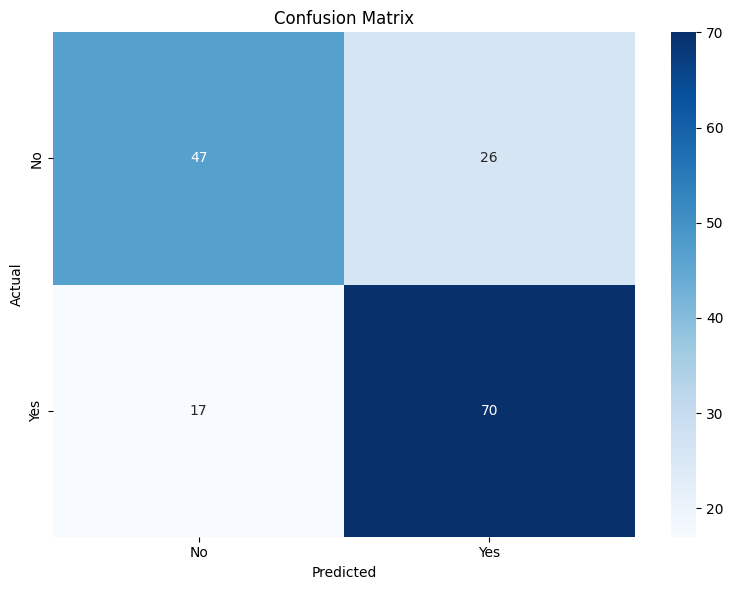

In [62]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()